# 01 - Paso a paso: del radar a las predicciones

Este notebook es el **primer paso** del flujo del curso. Aqui aprendemos a:

1. cargar una secuencia de radar y separarla en contexto + futuro,
2. construir una prediccion base de **persistencia**,
3. generar predicciones de **EarthFormer** y **CasCast** con un script,
4. visualizar las predicciones guardadas.

> Las **metricas** (RMSE, MAE, CSI, etc.) y la comparacion numerica se hacen en el notebook
> `03_comparacion_modelos_post_inferencia.ipynb`. Aqui solo *generamos y miramos* predicciones,
> sin repetir calculos.

**Antes de empezar** (ver `README.md`, secciones 1 a 3):

- Ambiente del curso instalado y activado (`nowcasting-course-lab`).
- Muestras descargadas: `python scripts/download_assets.py` -> `data/samples/`.
- Para los pasos 3 y 4 (EarthFormer/CasCast), checkpoints descargados:
  `python scripts/download_assets.py --checkpoints` -> `checkpoints/ef_ideam_final/`.
  El de difusion pesa ~3.9 GB, asi que conviene lanzarlo temprano (mientras instalas librerias).

La escala de colores usa umbrales discretos en mm/h: gris para 0-0.5, verde desde 0.5-2,
y colores calidos para lluvia mas intensa.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from course_utils.data import (
    SAMPLE_FILES,
    get_paths,
    load_sample,
    split_sequence,
    make_persistence_prediction,
)
from course_utils.palette import apply_course_style, RAIN_LEVELS
from course_utils.plotting import plot_event_grid

apply_course_style()
paths = get_paths(PROJECT_ROOT)

# Carpeta donde se guardan y leen las predicciones de este notebook.
# Es la misma que usa el script de inferencia y el notebook 03.
# Cambia a Path("/tmp/predicciones_01") si quieres una carpeta temporal aparte.
PRED_DIR = paths.prediction_dir

print(f"Proyecto: {paths.root}")
print(f"Muestras: {paths.sample_dir}")
print(f"Predicciones: {PRED_DIR}")

Proyecto: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab
Muestras: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab/data/samples
Predicciones: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab/outputs/predictions


## 1. Elegir un caso y mirar la tormenta

Cada archivo tiene **25 cuadros** separados por 5 minutos. Los primeros **13** son el contexto
observado (lo que el modelo "ve"); los ultimos **12** son el futuro real que queremos pronosticar
(hasta +60 min).

`split_sequence` hace exactamente ese corte: `inputs = sequence[:13]`, `target = sequence[13:25]`.

In [2]:
# Cambia el indice para mirar otro caso (hay 5 muestras en SAMPLE_FILES).
sample_name = SAMPLE_FILES[1]
sequence = load_sample(sample_name, paths)
inputs, target = split_sequence(sequence)

print("Caso:", sample_name)
print("Entrada (contexto):", inputs.shape, "  Target (futuro real):", target.shape)
print("Niveles de color mm/h:", RAIN_LEVELS)

Caso: barranca_seq_20240508_0600_patch_05_rain_rate.npy
Entrada (contexto): (13, 128, 128)   Target (futuro real): (12, 128, 128)
Niveles de color mm/h: [0.05, 0.5, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 60.0]


## 2. Persistencia: una linea base honesta

Antes de usar modelos profundos construimos el pronostico mas simple posible:
**persistencia** repite el ultimo cuadro observado para todos los tiempos futuros.

$$
\hat{Y}_{t+k} = X_t \qquad k = 1, 2, \dots, 12
$$

Si la tormenta se desplaza, persistencia falla de forma muy visual: conserva la forma pero la
deja en el lugar anterior. Es la referencia minima que un buen modelo debe superar.

`make_persistence_prediction` puede **guardar** el resultado directamente en disco con `save_to=...`,
para que despues lo carguemos igual que cualquier otro modelo.

In [3]:
persistence_path = PRED_DIR / "persistence" / sample_name
persistence = make_persistence_prediction(inputs, save_to=persistence_path)
print("Persistencia:", persistence.shape, "-> guardada en", persistence_path)

Persistencia: (12, 128, 128) -> guardada en /home/henryjuarez/code_andre_sophy/nowcasting_course_lab/outputs/predictions/persistence/barranca_seq_20240508_0600_patch_05_rain_rate.npy


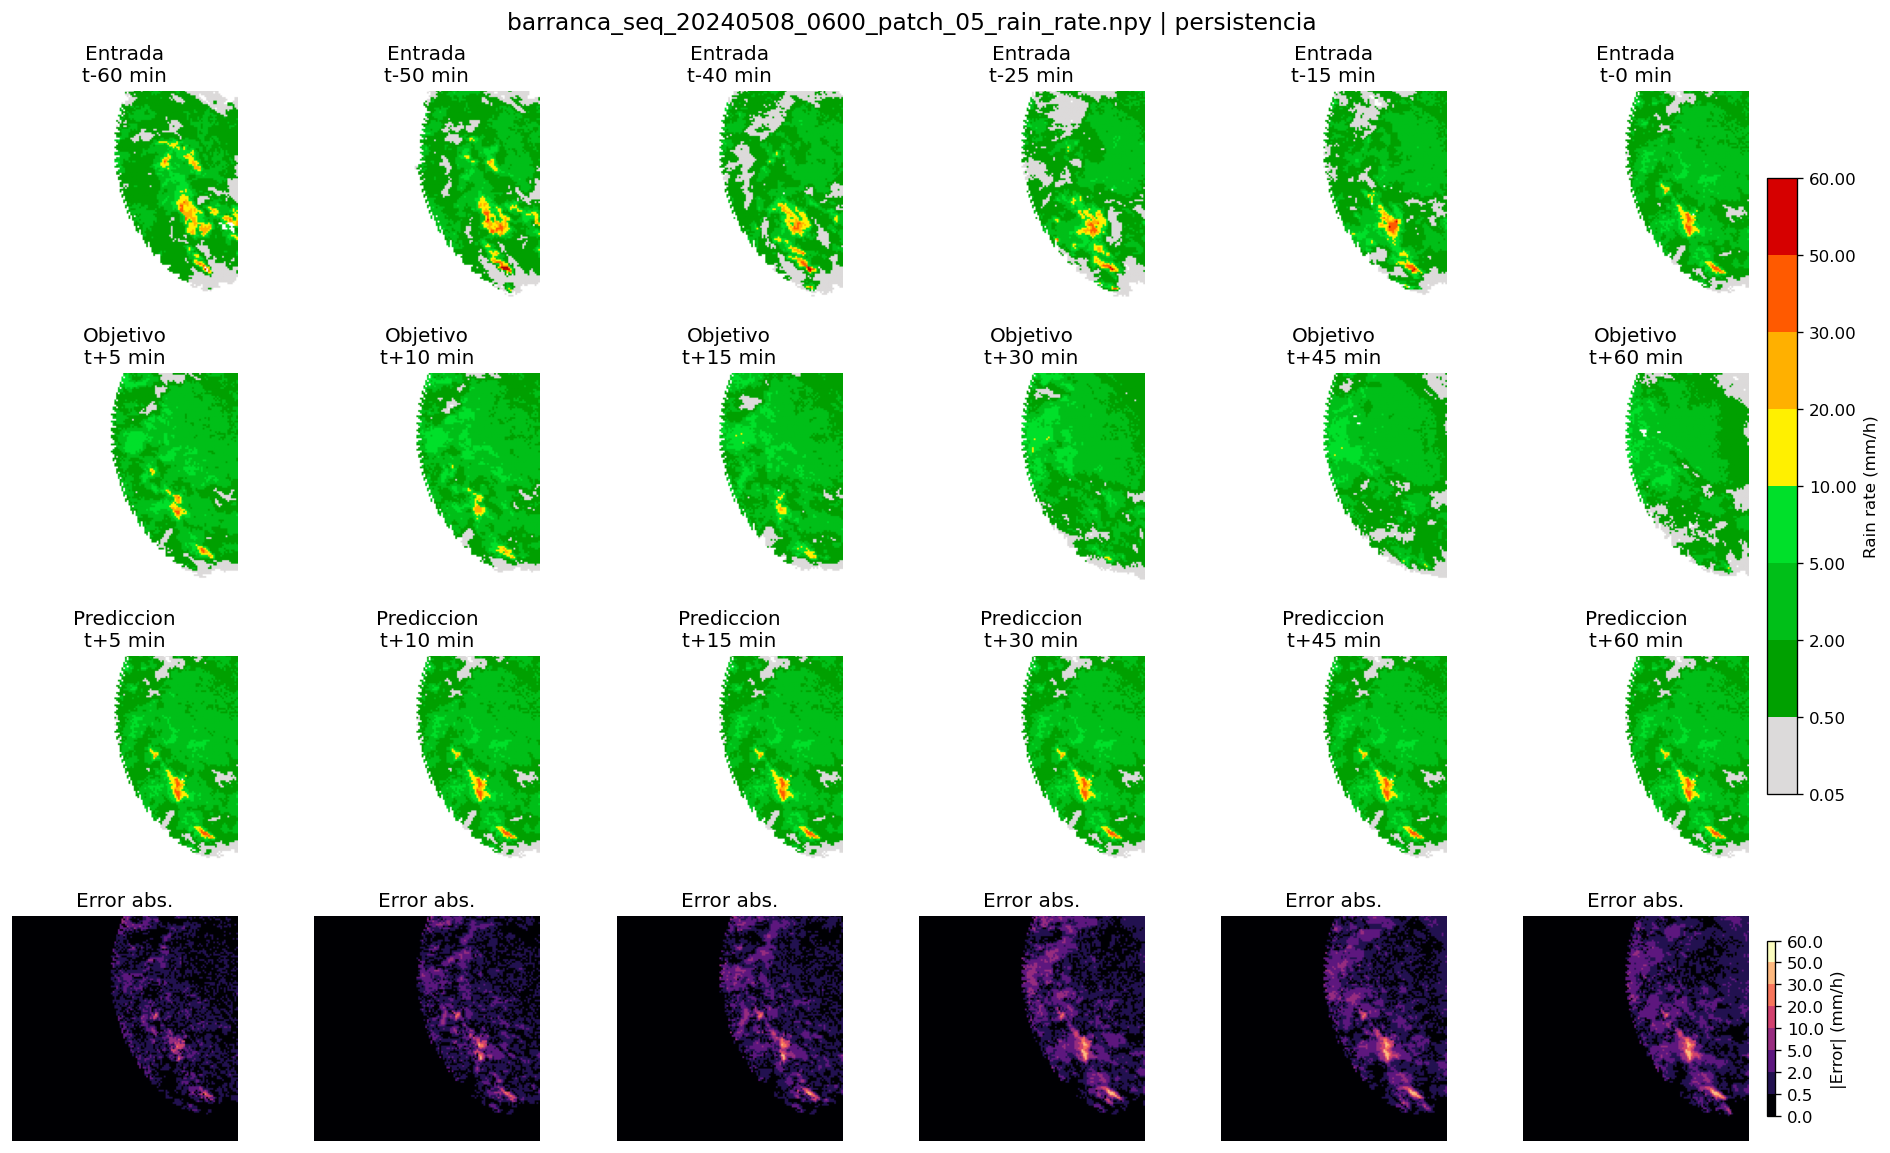

In [4]:
# plot_event_grid acepta una RUTA en disco y carga el .npy por ti.
# Filas: entrada (contexto) | objetivo real | prediccion | error absoluto.
fig = plot_event_grid(inputs, target, persistence_path, sample_name, "persistencia")
plt.show()

## 3. Generar predicciones de EarthFormer y CasCast

Las predicciones de los modelos profundos se generan **fuera del notebook**, con un script,
porque cargan checkpoints grandes (CasCast pesa varios GB) y pueden tardar.

El script `scripts/run_inference_from_list.py` lee un archivo de texto con **una ruta `.npy`
por linea** (formato en `scripts/sequences_example.txt`) y guarda las predicciones en
`outputs/predictions/{persistence,earthformer,cascast}/`, nombradas por el *stem* de cada archivo.

Desde una terminal, en la carpeta del curso y con el ambiente activado:

```bash
conda activate nowcasting-course-lab

# Solo EarthFormer (rapido, funciona en CPU):
python scripts/run_inference_from_list.py scripts/sequences_example.txt --stage earthformer

# EarthFormer + CasCast (difusion). En GPU:
python scripts/run_inference_from_list.py scripts/sequences_example.txt --stage all --ddim-steps 20 --device auto

# Si solo tienes CPU, empieza con pocos pasos para probar:
python scripts/run_inference_from_list.py scripts/sequences_example.txt --stage all --device cpu --ddim-steps 2 --cpu-threads 8
```

Para tus propios casos: copia `sequences_example.txt`, pon tus rutas `.npy` (absolutas o relativas
a la carpeta del curso, cada archivo de forma `(25,128,128)` en mm/h) y pasa ese archivo al script.

In [5]:
# Veamos la lista de ejemplo y que predicciones existen ya en disco para este caso.
example_list = paths.root / "scripts" / "sequences_example.txt"
print("Lista de ejemplo:", example_list)
print("-" * 60)
print(example_list.read_text())
print("-" * 60)

print(f"Predicciones en disco para {sample_name}:")
for label in ("persistence", "earthformer", "cascast", "model"):
    exists = (PRED_DIR / label / sample_name).exists()
    print(f"  {'OK' if exists else '--'}  {label}")

Lista de ejemplo: /home/henryjuarez/code_andre_sophy/nowcasting_course_lab/scripts/sequences_example.txt
------------------------------------------------------------
# Lista de secuencias para run_inference_from_list.py
# -----------------------------------------------------
# - Una ruta .npy por linea. Cada archivo debe ser (25, 128, 128) en mm/h.
# - Las lineas que empiezan con # se ignoran. Las lineas vacias tambien.
# - Las rutas relativas se resuelven desde donde ejecutas el comando
#   (ejecuta desde la raiz del repo: nowcasting_course_lab/).
#
# Uso:
#   python scripts/run_inference_from_list.py scripts/sequences_example.txt --stage all
#
# Puedes copiar este archivo y poner tus propias rutas (incluso absolutas).

data/samples/barranca_seq_20240426_2000_patch_04_rain_rate.npy
data/samples/barranca_seq_20240508_0600_patch_05_rain_rate.npy
data/samples/barranca_seq_20240512_0800_patch_03_rain_rate.npy
data/samples/guaviare_seq_20240329_0700_patch_05_rain_rate.npy
data/samples/guav

## 4. Cargar y visualizar las predicciones guardadas

Una vez generadas, cargamos cada prediccion **desde disco** y la dibujamos junto al objetivo
real y al error absoluto. Si EarthFormer o CasCast todavia no existen, simplemente se saltan
(no hay error). Vuelve a correr esta celda despues de ejecutar el script del paso 3.

Mostrando: ['persistence', 'earthformer', 'cascast']


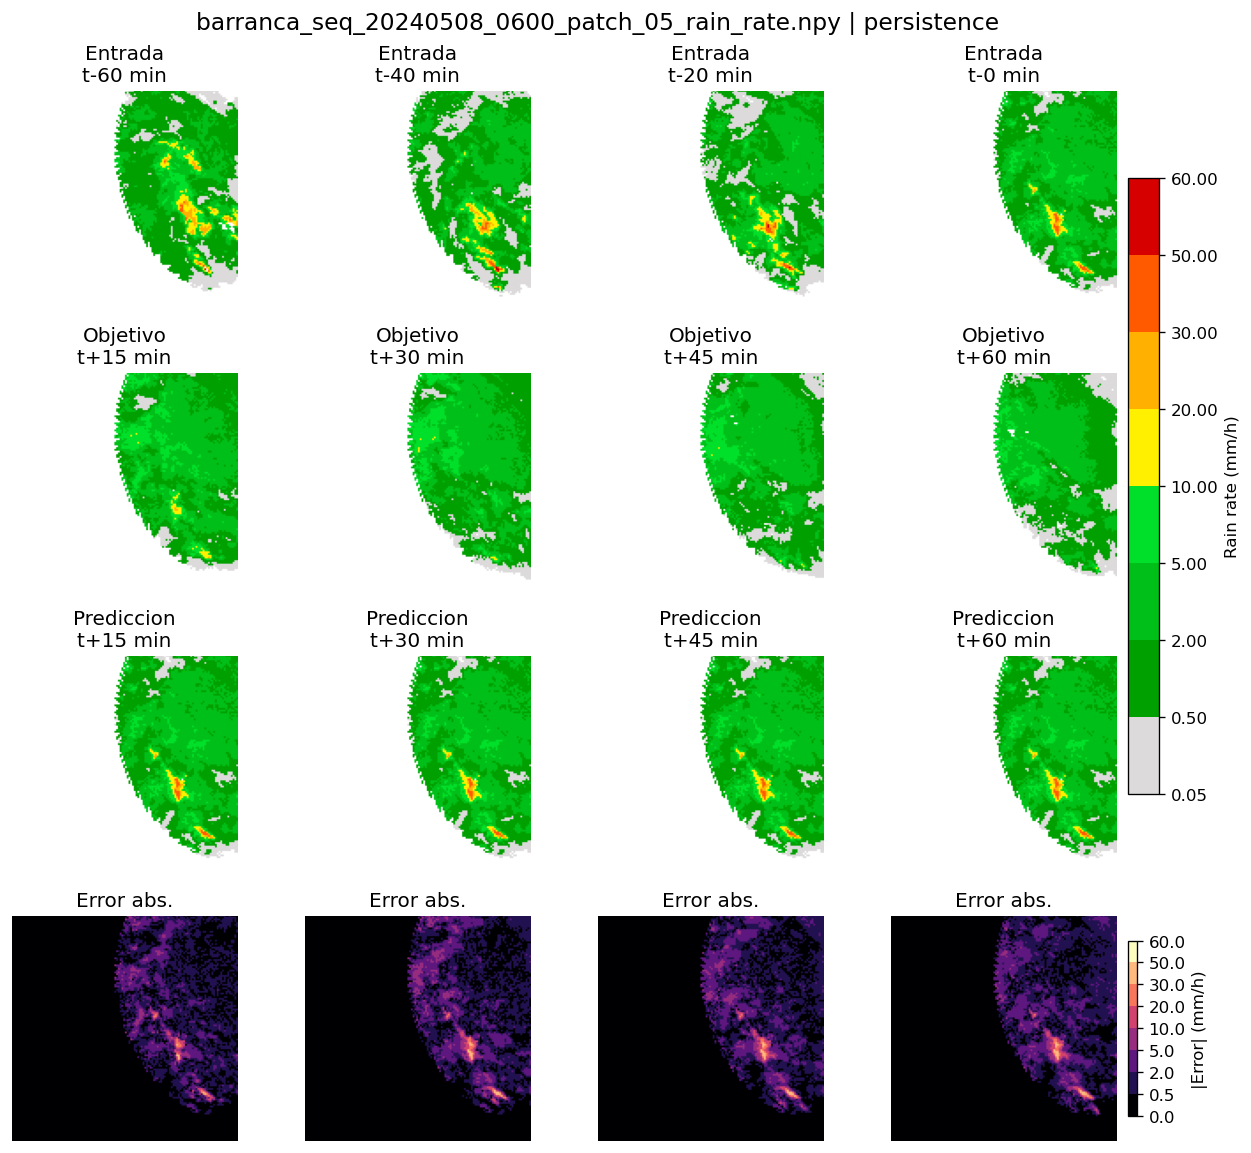

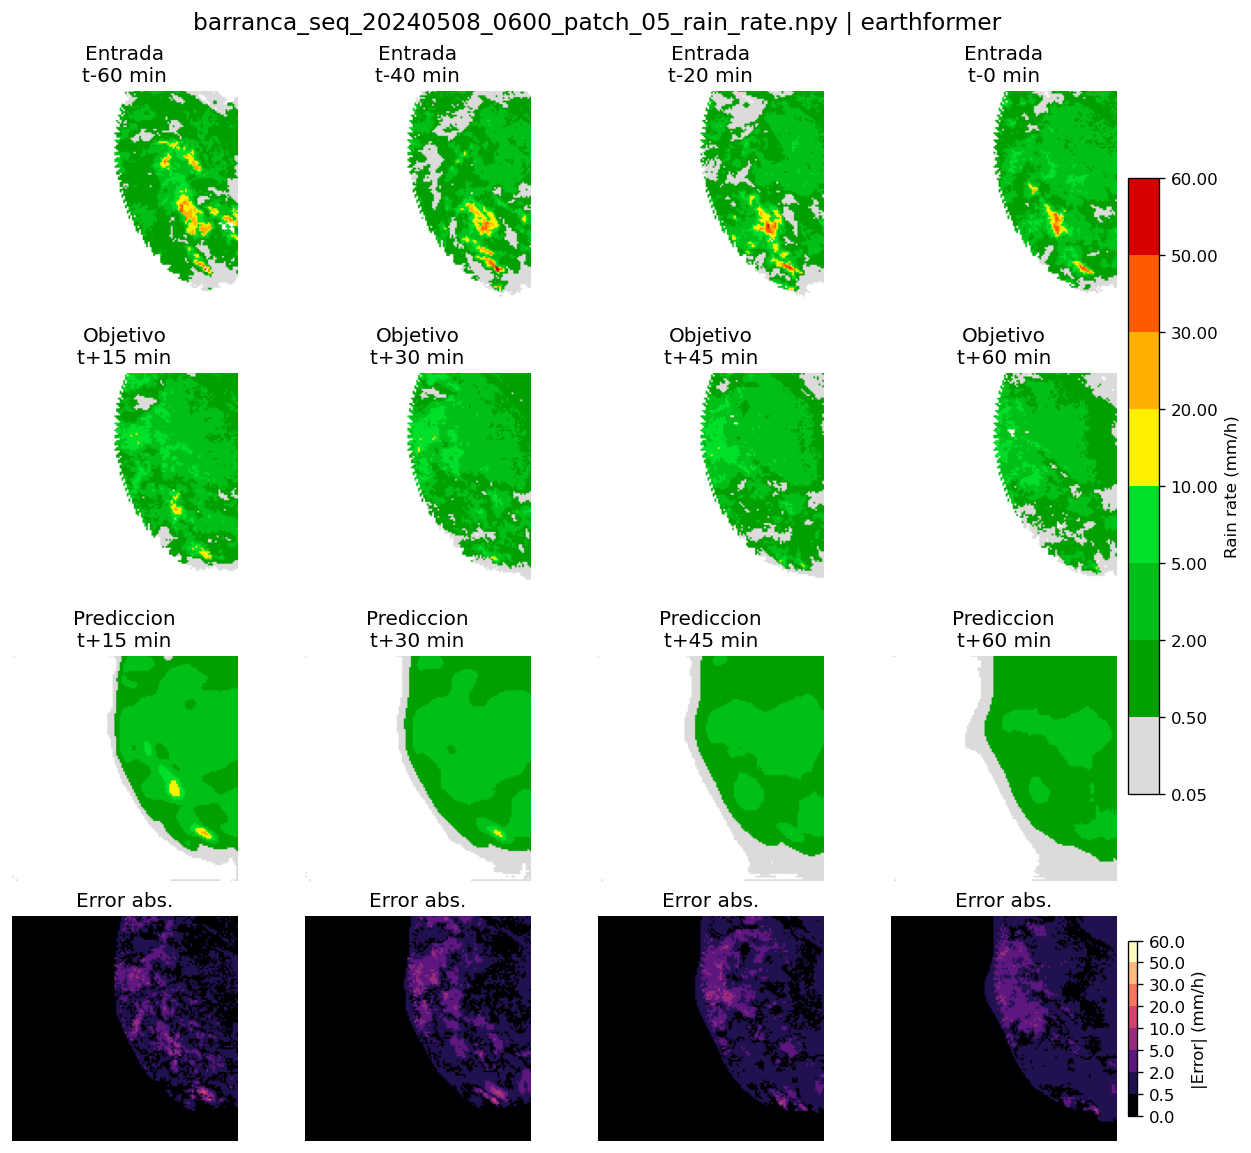

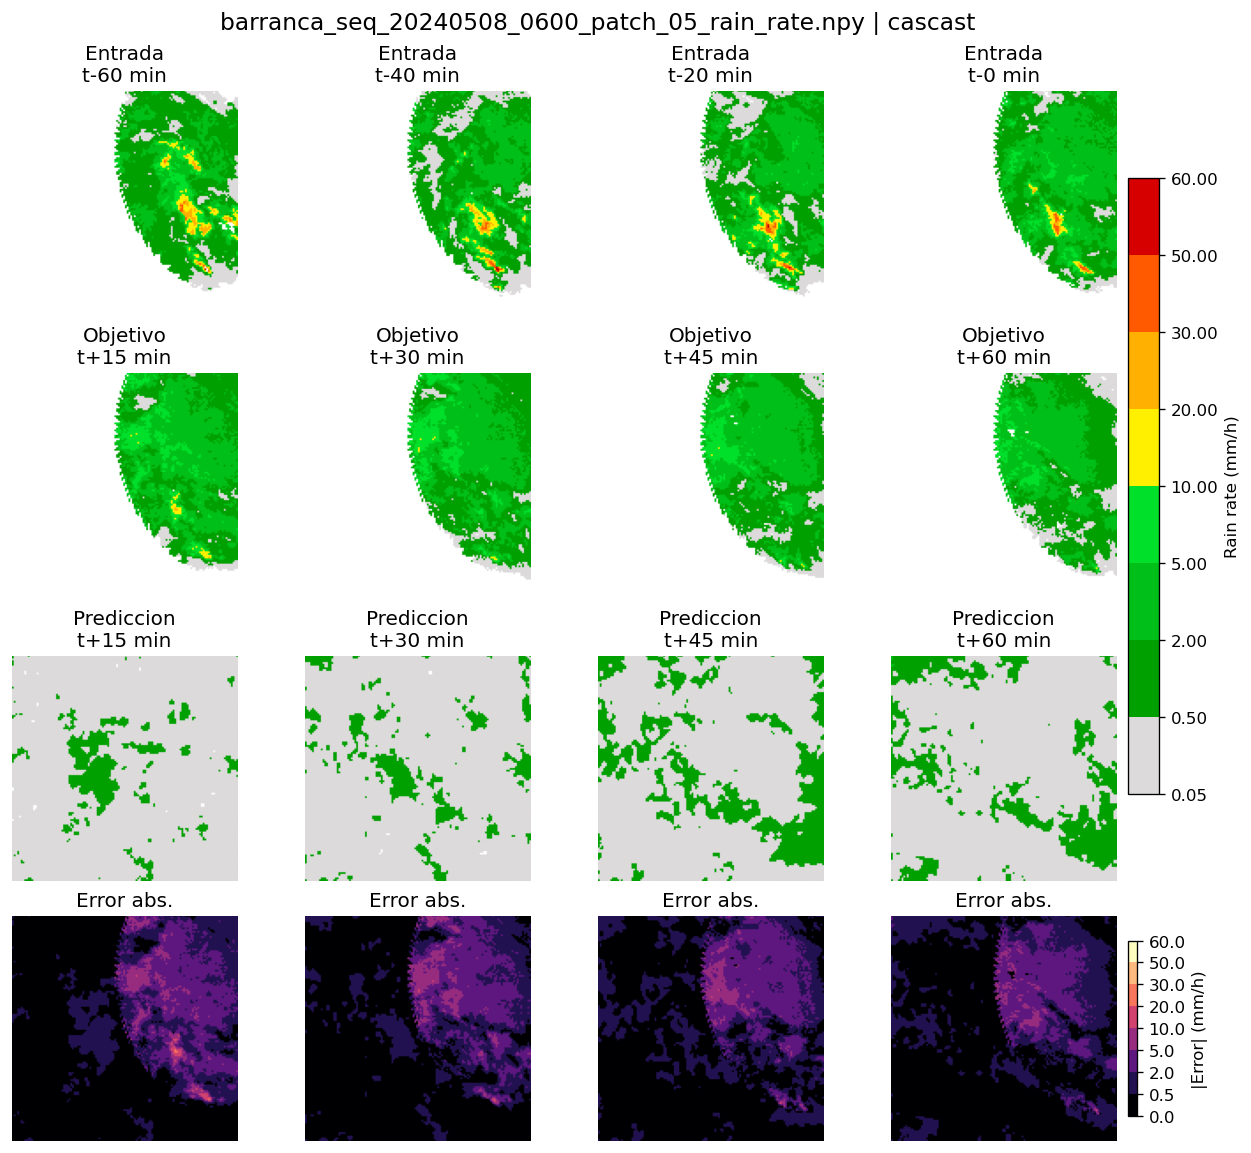

In [6]:
models_to_show = [
    label for label in ("persistence", "earthformer", "cascast", "model")
    if (PRED_DIR / label / sample_name).exists()
]
print("Mostrando:", models_to_show)

for label in models_to_show:
    fig = plot_event_grid(
        inputs, target,
        PRED_DIR / label / sample_name,
        sample_name, label,
        lead_indices=(2, 5, 8, 11),
    )
    plt.show()

if models_to_show == ["persistence"]:
    print(
        "\nSolo existe persistencia. Corre scripts/run_inference_from_list.py (paso 3) "
        "para generar EarthFormer/CasCast y vuelve a ejecutar esta celda."
    )

## 5. Cierre

- **Persistencia** es el minimo honesto: repite el ultimo radar y suele perder el desplazamiento.
- **EarthFormer** aprende movimiento y estructura de mesoescala.
- **CasCast** usa difusion para recuperar detalle y realismo de pequena escala.

Ya tienes predicciones guardadas en `outputs/predictions/`. El siguiente paso es **medir** cual
es mejor y por que: abre `notebooks/03_comparacion_modelos_post_inferencia.ipynb`, donde
calculamos RMSE, MAE, sesgo, correlacion y CSI **una sola vez** y comparamos los modelos.